In [1]:
import os, sys, json
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
sys.path.append("..")
matplotlib.rcParams ['pdf.fonttype'] = 42
matplotlib.rcParams ['ps.fonttype'] = 42

/home/zczhang/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
# read from json
data = None
experiment_name = "fig3"
with open("../../../output/oscar-nsdi26/experiments/" + experiment_name + ".json", "r") as f:
    data = json.load(f)

In [3]:
# Calculate the send rate from data{flowStatistics:[0:4]:sentPkt:[timeNs,sizeByte]}
# The send rate is calculated by the number Bytes sent in each time interval
send_rate_interval_ns = 1.5e4  # 10us
send_rate = []
flow_num = 5
for i in range(flow_num):
    send_rate.append([])
    wnd_start = data["flowStatistics"][i]["sentPkt"][0]["timeNs"]
    # the first point
    send_rate[i].append({"timeNs": wnd_start, "sendRateGbps": 0})
    wnd_data = 0
    for sentPkt in data["flowStatistics"][i]["sentPkt"]:
        if sentPkt["timeNs"] - wnd_start > 2*send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            send_rate[i].append({"timeNs": sentPkt["timeNs"],
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        elif sentPkt["timeNs"] - wnd_start > send_rate_interval_ns:
            # Gbps = bpns
            send_rate[i].append({"timeNs": wnd_start + (sentPkt["timeNs"] - wnd_start)/2,
                                "sendRateGbps": wnd_data * 8 / (sentPkt["timeNs"] - wnd_start)})
            wnd_start = sentPkt["timeNs"]
            wnd_data = 0
        wnd_data += sentPkt["sizeByte"]
    # the last point
    send_rate[i].append({"timeNs": wnd_start + send_rate_interval_ns/2,
                         "sendRateGbps": 0})

In [4]:
# caculate the delay gradient in TIMELY manner
gradient_timely = []
interval_pkts = 64
rtt_diff = 0
alpha = 0.875
pkt_count = 0 # the number of packets in the interval
base_rtt = 12e3
flow_idx = 0
prev_rtt = data["flowStatistics"][flow_idx]["ccStats"]["delay"][0]["delayNs"]
for delay in data["flowStatistics"][flow_idx]["ccStats"]["delay"]:
    pkt_count += 1
    if pkt_count == interval_pkts:
        # Calculate the delay gradient as TIMELY does
        new_rtt = delay["delayNs"]
        new_rtt_diff = new_rtt - prev_rtt
        rtt_diff = alpha * new_rtt_diff + (1 - alpha) * rtt_diff
        gradient = rtt_diff / base_rtt
        gradient_timely.append({#"timeNs": np.mean(wnd_recv_time),
                               "timeNs": delay["sendTimeNs"],
                               "delay": gradient})
        prev_rtt = new_rtt
        pkt_count = 0

In [5]:
# the delay gradiet need to be calculated by the delay using windowbased least square
# which is in data["flowStatistics"][flow_idx]["ccStats"]["delay"]
def least_square(xs, ys):
    # assemble matrix A
    A = np.vstack([xs, np.ones(len(xs))]).T
    # turn y into a column vector
    ys = np.array(ys)
    y = ys[:, np.newaxis]

    alpha = np.linalg.lstsq(A, y, rcond=None)[0]
    return alpha


flow_idx = 0
delay_gradient = []
delay_gradient_interval_ns = 1e3  # 10us window
wnd_start = data["flowStatistics"][flow_idx]["ccStats"]["delay"][0]["sendTimeNs"]
wnd_xs = []
wnd_ys = []
wnd_recv_time = []
for delay in data["flowStatistics"][flow_idx]["ccStats"]["delay"]:
    if delay["sendTimeNs"] - wnd_start > delay_gradient_interval_ns:
        # Calculate the delay gradient in the window and reset the window
        delay_gradient.append({  # "timeNs": np.mean(wnd_recv_time),
            "timeNs": wnd_xs[-1],
            "delay": least_square(wnd_xs, wnd_ys)[0][0]})
        wnd_start = delay["sendTimeNs"]
        wnd_xs = []
        wnd_ys = []
        wnd_recv_time = []
    wnd_xs.append(delay["sendTimeNs"])
    wnd_ys.append(delay["delayNs"])
    wnd_recv_time.append(delay["recvTimeNs"])
# the last interval
delay_gradient.append({"timeNs": wnd_start + delay_gradient_interval_ns/2,
                       "delay": least_square(wnd_xs, wnd_ys)[0][0]})

ideal_r = [{
    "timeNs": 0e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 500e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 500e3,
    "sendRateGbps": 1000
},
    {
    "timeNs": 550e3,
    "sendRateGbps": 1000
},
    {
    "timeNs": 550e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 1500e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 1500e3,
    "sendRateGbps": 10
},
    {
    "timeNs": 1550e3,
    "sendRateGbps": 10
},
    {
    "timeNs": 1550e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 2000e3,
    "sendRateGbps": 100
}]


In [6]:
ideal_w = [{
    "timeNs": 0e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 500e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 500e3,
    "sendRateGbps": 990
},
    {
    "timeNs": 550e3,
    "sendRateGbps": 990
},
    {
    "timeNs": 550e3,
    "sendRateGbps": 200
},
    {
    "timeNs": 1500e3,
    "sendRateGbps": 200
},
    {
    "timeNs": 1500e3,
    "sendRateGbps": 20
},
    {
    "timeNs": 1550e3,
    "sendRateGbps": 20
},
    {
    "timeNs": 1550e3,
    "sendRateGbps": 100
},
    {
    "timeNs": 2000e3,
    "sendRateGbps": 100
}]


In [7]:
color_rate = ["#F44336", "#F9A825"]
color_queue = ["#4E342E", "#FB8C00"]
timely_color = "#757575"
shadow_color = ["#81C784", "#BDBDBD"]
line = ["-", "--"]
time_shift = 100e3



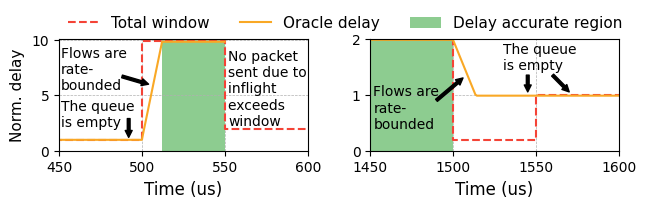

In [8]:
# draw the rise of the congestion in one figure
fig, axs = plt.subplots(1, 2, figsize=(7, 1.4))
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.25,
                    hspace=0.5)

figure_time_shift = 0


ax1 = axs[0]
ax1.set_xlabel("Time (us)", fontsize=12)
ax1.plot([r["timeNs"] / 1e3 - figure_time_shift for r in ideal_w],
         [r["sendRateGbps"]/100 for r in ideal_w], label="Ideal", color=color_rate[0], linestyle=line[1])
ax1.plot([u["sendTimeNs"]/1e3 - time_shift - figure_time_shift for u in 
          data["flowStatistics"][flow_idx]["ccStats"]["delay"] 
          if u["sendTimeNs"]/1e3 - time_shift - figure_time_shift < 550],
         [u["delayNs"]/12.4e3 for u in 
          data["flowStatistics"][flow_idx]["ccStats"]["delay"] 
          if u["sendTimeNs"]/1e3 - time_shift - figure_time_shift < 550], 
         label="HPCC", color=color_rate[1], linestyle=line[0])
figure_congestion_start = 500 - figure_time_shift
ax1.fill_between([figure_congestion_start+12, figure_congestion_start+50],
                 0.0, 10, facecolor=shadow_color[0], alpha=0.9)
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax1.annotate('Flows are \nrate-\nbounded', xy=(506, 5), xytext=(451, 5.5),
             xycoords='data',)
ax1.annotate('', xy=(504, 6), xytext=(488, 6.7),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)

ax1.annotate('The queue\nis empty', xy=(506, 5), xytext=(451, 2.15),
             xycoords='data',)
ax1.annotate('', xy=(492, 1.2), xytext=(492, 2.9),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)

ax1.set_xlim(450, 600)
ax1.set_ylim(0, 10.1)
ax2 = axs[1]
ax2.set_xlabel("Time (us)", fontsize=12)
ax2.plot([r["timeNs"] / 1e3 - figure_time_shift for r in ideal_w],
         [r["sendRateGbps"]/100 for r in ideal_w], label="Ideal", color=color_rate[0], linestyle=line[1])
ax2.plot([u["sendTimeNs"]/1e3 - time_shift - figure_time_shift for u in data["flowStatistics"][flow_idx]["ccStats"]["delay"]],
         [u["delayNs"]/12.4e3 for u in data["flowStatistics"][flow_idx]["ccStats"]["delay"]], label="HPCC", color=color_rate[1], linestyle=line[0])
ax2.fill_between([1450, 1500],
                 0.0, 10, facecolor=shadow_color[0], alpha=0.9, label="xx")

ax2.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax2.annotate('Flows are \nrate-\nbounded', xy=(1506, 1.3), xytext=(1452, 0.4),
             xycoords='data',)
ax2.annotate('', xy=(1506, 1.3), xytext=(1490, 0.9),
             xycoords='data', arrowprops=dict(facecolor='black', shrink=0,
                                              width=2, headlength=5, headwidth=5),)

ax2.annotate('The queue\nis empty', xy=(1530, 1.05), xytext=(1530, 1.45),
             xycoords='data',)
ax2.annotate('', xy=(1545, 1.05), xytext=(1545, 1.35),
             xycoords='data', arrowprops=dict(facecolor='black', shrink=0,
                                              width=2, headlength=5, headwidth=5),)
ax2.annotate('', xy=(1570, 1.05), xytext=(1560, 1.35),
             xycoords='data', arrowprops=dict(facecolor='black', shrink=0,
                                              width=2, headlength=5, headwidth=5),)


fig.text(0.03, 0.5, "Norm. delay", va='center',
         rotation='vertical', fontsize=11, fontstretch='expanded')

ax2.set_ylim(0, 2)
ax2.set_xlim(1450, 1600)
ax2.set_yticks([0, 1, 2])

handles, _ = ax2.get_legend_handles_labels()
labels = ["Total window", "Oracle delay", "Delay accurate region"]
order = [0, 1, 2]
plt.legend([handles[idx] for idx in order], [labels[idx] for idx in order],
           loc='center', ncol=3, frameon=False, bbox_to_anchor=(-0.1, 1.14), prop={'size': 11})

ax1.annotate('No packet \nsent due to \ninflight \nexceeds \nwindow', xy=(506, 5), xytext=(552, 2.3),
             xycoords='data',)

plt.savefig("../figures/" + "fig3a" +
            ".pdf", bbox_inches='tight', pad_inches=0.0, dpi=600, format='pdf')

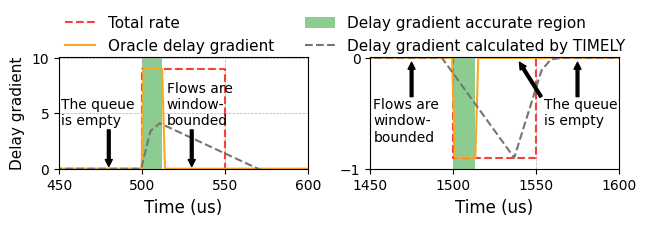

In [9]:
# draw the rise of the congestion in one figure
fig, axs = plt.subplots(1, 2, figsize=(7, 1.4))
plt.subplots_adjust(left=0.1,
                    bottom=0.1,
                    right=0.9,
                    top=0.9,
                    wspace=0.25,
                    hspace=0.5)

figure_time_shift = 0


ax1 = axs[0]
ax1.set_xlabel("Time (us)", fontsize=12)
ax1.set_xlabel("Time (us)")
ax1.plot([r["timeNs"] / 1e3 for r in ideal_r],
         [r["sendRateGbps"]/100-1 for r in ideal_r], label="Ideal", color=color_rate[0], linestyle=line[1])
ax1.plot([u["timeNs"]/1e3 - time_shift for u in delay_gradient],
         [u["delay"] for u in delay_gradient], label="HPCC", color=color_rate[1], linestyle=line[0])
timely_line = ax1.plot([u["timeNs"]/1e3 - time_shift for u in gradient_timely],
                       [u["delay"] for u in gradient_timely], label="HPCC", color=timely_color, linestyle=line[1])
figure_congestion_start = 500 - figure_time_shift
ax1.fill_between([figure_congestion_start,figure_congestion_start+12],0.0,10,facecolor = shadow_color[0], alpha = 0.9)
ax1.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')

ax1.annotate('The queue\nis empty', xy=(506, 5), xytext=(451, 4),
             xycoords='data',)
ax1.annotate('', xy=(480, 0.2), xytext=(480, 3.5),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)
ax1.annotate('Flows are \nwindow-\nbounded', xy=(506, 5), xytext=(515, 4),
             xycoords='data',)
ax1.annotate('', xy=(530, 0.2), xytext=(530, 3.5),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)

ax1.set_xlim(450, 600)
ax1.set_ylim(0, 10.1)

ax2 = axs[1]
ax2.set_xlabel("Time (us)", fontsize=12)
ax2.plot([r["timeNs"] / 1e3 for r in ideal_r],
         [r["sendRateGbps"]/100-1 for r in ideal_r], label="Ideal", color=color_rate[0], linestyle=line[1])
ax2.plot([u["timeNs"]/1e3 - time_shift for u in delay_gradient],
         [u["delay"] for u in delay_gradient], label="HPCC", color=color_rate[1], linestyle=line[0])
ax2.fill_between([figure_congestion_start,figure_congestion_start+12],0.0,10,facecolor = shadow_color[0], alpha = 0.9, label="xx")
ax2.plot([u["timeNs"]/1e3 - time_shift for u in gradient_timely],
         [u["delay"] for u in gradient_timely], label="HPCC", color=timely_color, linestyle=line[1])
ax2.fill_between([1500,1513.2],-1,0.01,facecolor = shadow_color[0], alpha = 0.9)

ax2.grid(True, linestyle='--', linewidth=0.5, which='both', axis='both')


handles, _ = ax2.get_legend_handles_labels()
labels = ["Total rate", "Oracle delay gradient", "Delay gradient accurate region", "Delay gradient calculated by TIMELY"]
order = [0,1,2,3]
plt.legend([handles[idx] for idx in order],[labels[idx] for idx in order],
            loc='center', ncol=2, frameon=False, bbox_to_anchor=(-0.1, 1.2), prop={'size': 11})

fig.text(0.03, 0.5, "Delay gradient", va='center',
         rotation='vertical', fontsize=11, fontstretch='expanded')

ax2.set_ylim(-1, 0.01)
ax2.set_xlim(1450, 1600)
ax2.set_yticks([-1, 0])

ax2.annotate('Flows are \nwindow-\nbounded', xy=(1506, -0.6), xytext=(1452, -0.75),
             xycoords='data',)
ax2.annotate('', xy=(1475, -0.04), xytext=(1475, -0.35),
             xycoords='data',
             arrowprops=dict(facecolor='black', shrink=0,
                             width=2, headlength=5, headwidth=5),)
ax2.annotate('The queue\nis empty', xy=(1530, -0.04), xytext=(1555, -0.6),
             xycoords='data',)
ax2.annotate('', xy=(1540, -0.04), xytext=(1553, -0.35),
             xycoords='data', arrowprops=dict(facecolor='black', shrink=0,
                                              width=2, headlength=5, headwidth=5),)
ax2.annotate('', xy=(1575, -0.04), xytext=(1575, -0.35),
             xycoords='data', arrowprops=dict(facecolor='black', shrink=0,
                                              width=2, headlength=5, headwidth=5),)

plt.savefig("../figures/" + "fig3b" +
             ".pdf", bbox_inches='tight', pad_inches=0.0, dpi=600, format='pdf')